# Modern Pipeline - Complete Workflow

This notebook demonstrates the **modern approach** to data processing using the complete toolkit.

**One command instead of manual processing for each dataset!**

# Table of Contents
1. [Part 1: Complete Modern Pipeline (One Command!)](#Part-1:-Process-All-Datasets)
2. [Part 2: Data Quality Report](#Part-2:-Data-Quality-Report)
3. [Part 3: Summary Statistics](#Part-3:-Summary-Statistics:-Describing-the-Data)
4. [Part 4: Augmented Dickey-Fuller Stationarity Tests](#Part-4:-Stationarity-Tests:-A-Critical-Assumption-for-Time-Series)
5. [Part 5: Create Lags and Check Panel Balance](#Part-5:-Creating-Lag-Variables-for-Dynamic-Models)
6. [Part 6: Visualisation and Descriptive Analysis](#Part-6:-Exploratory-Visualisation)
7. [Part 7: Main Regression Analysis (Levels and Interacted)](#Part-7:-Heterogeneity-Regressions)
    - [Baseline Regressions: The Average Effect](#Baseline-Regressions:-The-Average-Effect-of-Globalisation)
    - [Welfare Regime Interactions: Heterogeneity Analysis](#Panel-Fixed-Effects-Regression-with-Welfare-Regime-Interactions)
    - [Robustness Checks: Sensitivity Analysis](#Robustness-Checks:-Testing-the-Stability-of-Our-Results)
8. [Part 8: Feedback Regressions (Reverse Causality)](#Part-8:-Feedback-Regressions)
9. [Part 9: Export to R / Stata](#Part-9:-Exporting-for-Other-Statistical-Software)


## Setup: Configuring the Project Environment

Before any analysis can begin, we need to tell Python where our custom source code lives.

The cell below performs two critical tasks:
1. **Sets the repository root** — Using `pathlib.Path`, we establish an absolute reference point (`REPO_ROOT`) so all file paths (data, outputs) are portable and reproducible regardless of where the notebook is opened from.
2. **Adds `src/` to `sys.path`** — Our reusable data-cleaning functions live in `src/clean/` and `src/analysis/`. By appending this directory to `sys.path`, we can `import` them directly (e.g., `from clean import process_all_datasets`) without needing to install them as a package.

> **Why this matters:** Keeping analysis code in a separate `src/` directory (rather than inline in the notebook) makes the code testable, reusable across notebooks, and easier to version-control.

In [1]:
from pathlib import Path
import sys

# Setup paths
REPO_ROOT = Path.cwd().resolve().parent
SRC_PATH = REPO_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

print(f"Repository root: {REPO_ROOT}")

Repository root: C:\Users\Anton\economics-of-the-welfare-state


## Part 1: Modern Pipeline (ONE COMMAND!)

Process all 6 datasets with a single function call:

### Merging into a Master Dataset

Each dataset has been cleaned individually, but they need to be combined into a single **master panel dataset** before analysis.

The merge uses `(iso3, year)` as the join key — the standard identifier pair for country-year panel data. We use an **outer join** (`how='outer'`) to retain all available observations, even if some countries or years are missing from a particular source.

> **Trade-off:** An outer join maximises coverage but introduces `NaN` values where data sources don't overlap. The Data Quality Report (Part 2) will quantify exactly how much missingness this creates.

After merging, we save the master dataset in three formats:
- **Parquet** — Efficient binary format, ideal for Python/pandas workflows
- **CSV** — Universal plain-text format, readable by any software
- **Stata (.dta)** — For researchers using Stata for econometric analysis

### Processing All Datasets

The `process_all_datasets()` function is the backbone of this pipeline. With a single call, it:

| Step | What it does |
|---|---|
| **Load** | Reads each raw dataset from `data/raw/` (CPDS, World Bank, KOF, etc.) |
| **Clean** | Standardises country codes to ISO3, harmonises year ranges, handles encoding issues |
| **Validate** | Checks for duplicate rows, missing key columns, and unexpected data types |
| **Transform** | Applies log transformations (e.g., GDP per capita → `ln_gdppc`) where appropriate |
| **Save** | Writes each cleaned dataset to `data/processed/` as `.parquet` files |

**Parameters explained:**
- `start_year` / `end_year`: Restricts all datasets to this window, ensuring temporal alignment.
- `validate=True`: Enables automated data quality checks during processing.
- `save_outputs=True`: Persists cleaned datasets so subsequent runs can skip re-processing.

> **Datasets included:** CPDS (social spending, fiscal variables), Population (World Bank), GDP per capita (World Bank), Inflation CPI (World Bank), Dependency Ratio (World Bank), KOF Globalisation Index (ETH Zürich).

In [2]:
from clean import process_all_datasets, merge_all_datasets

# Process ALL datasets with one command!
results = process_all_datasets(
    repo_root=REPO_ROOT,
    year_min=1980,
    year_max=2023,
    validate=True,
    save_outputs=True
)

print(f"\n Processed {len(results)} datasets!")
for name, df in results.items():
    if df is not None:
        print(f"   {name}: {len(df):,} observations")

⚠️  Calamine read failed: No module named 'calamine'

 Processed 6 datasets!
   cpds: 1,310 observations
   population: 1,408 observations
   gdppc: 1,408 observations
   inflation: 1,408 observations
   dependency: 1,088 observations
   kof: 1,340 observations


In [3]:
# Merge into master dataset
master = merge_all_datasets(results, how='outer')

print(f"\n Master Dataset:")
print(f"   {len(master):,} observations")
print(f"   {master['iso3'].nunique()} countries")
print(f"   {master['year'].min()}-{master['year'].max()}")
print(f"   {len(master.columns)} variables")
master.head()

Starting merge with cpds: 1310 rows
Merged population: 1310 → 1408 rows
Merged gdppc: 1408 → 1408 rows
Merged inflation: 1408 → 1408 rows
Merged dependency: 1408 → 1408 rows
Merged kof: 1408 → 1408 rows

✅ Final merged dataset: 1408 rows, 18 columns
   Countries: 32
   Years: 1980-2023

 Master Dataset:
   1,408 observations
   32 countries
   1980-2023
   18 variables


,iso3,year,sstran,deficit,debt,ln_population,ln_gdppc,inflation_cpi,dependency_ratio,KOFGI,KOFEcGI,KOFTrGI,KOFFiGI,KOFSoGI,KOFIpGI,KOFInGI,KOFCuGI,KOFPoGI
0,AUS,1980,6.354030,-2.278132,NaN,16.502814,4.789221,10.135840,NaN,62.259674,46.758671,48.250042,45.267303,65.066986,54.277916,58.188461,81.380493,75.070831
1,AUS,1981,6.342545,-2.686287,NaN,16.518432,4.800729,9.487666,NaN,62.196213,47.319584,47.269646,47.369522,64.980812,54.544571,58.197704,80.889000,74.404846
2,AUS,1982,7.221219,-3.736494,NaN,16.535769,4.767873,11.351820,NaN,62.148006,47.408798,46.937378,47.880219,65.245987,54.825874,58.230247,81.372437,73.919006
3,AUS,1983,7.426542,-4.924803,NaN,16.549454,4.777743,10.038910,NaN,62.404575,48.223728,46.599045,49.848408,65.259773,54.880436,58.252586,81.342079,73.849777
4,AUS,1984,7.250438,-4.871285,NaN,16.561460,4.778012,3.960396,NaN,62.434082,49.074951,46.908257,51.241638,65.311806,55.151432,58.289711,81.217270,73.036034


### Save Master Dataset

Save the cleaned and merged data for future use in multiple formats (Parquet, CSV, Stata).

In [4]:
from clean import save_master_dataset

# Save the master dataset
saved_paths = save_master_dataset(
    master, 
    output_path=REPO_ROOT / "data" / "final" / "master_dataset",
    formats=['parquet', 'csv', 'stata']
)

✅ Saved: C:\Users\Anton\economics-of-the-welfare-state\data\final\master_dataset.parquet
✅ Saved: C:\Users\Anton\economics-of-the-welfare-state\data\final\master_dataset.csv
✅ Saved: C:\Users\Anton\economics-of-the-welfare-state\data\final\master_dataset.dta


## Part 1.5: Research Diagnostics (Stationarity & Normality)

Before proceeding to regressions, we must verify the statistical properties of our variables. 
The **Im-Pesaran-Shin (IPS)** test is used to check for unit roots in panel data. 
- **I(0)**: Stationary (Good for levels regression)
- **I(1)**: Non-stationary (May require first-differencing)

We also run the **Jarque-Bera** test to check for normality.

We also calculate **Variance Inflation Factor (VIF)** to check for Multicollinearity among our regressors.

In [5]:
from clean import generate_diagnostic_report, export_diagnostics_latex, export_vif_latex
from clean.utils import load_config

config = load_config()
key_vars = ["sstran"] + config.get("controls", [])

# Generate diagnostic report for all key variables
diagnostic_df = generate_diagnostic_report(master, key_vars)

# Also generate and save a publication-ready LaTeX table for Overleaf
export_diagnostics_latex(master, key_vars, out_dir=REPO_ROOT / "outputs" / "tables")

# Check for Multicollinearity across different model specifications (VIF > 10 is problematic)
export_vif_latex(master, config.get("indices", []), config.get("controls", []), out_dir=REPO_ROOT / "outputs" / "tables")



📊 GENERATING RESEARCH DIAGNOSTIC REPORT
        Variable  Missing (%) Stationarity  ADF mean p-value  Normality
          sstran         10.1     I(1) ⚠️             0.3066 Skewed ⚠️ 
        ln_gdppc          8.2     I(1) ⚠️             0.5073 Skewed ⚠️ 
   inflation_cpi          6.9       I(0) ✅            0.0817 Skewed ⚠️ 
         deficit         11.2       I(0) ✅            0.0886 Skewed ⚠️ 
            debt         12.8     I(1) ⚠️             0.5533 Skewed ⚠️ 
   ln_population          0.0     I(1) ⚠️             0.7459   Normal ✅
dependency_ratio         22.7     I(1) ⚠️             0.5233 Skewed ⚠️ 
------------------------------------------------------------
Interpretation: I(0) = Stationary, I(1) = Non-stationary (Unit Root)
Normal: p > 0.05 (H0: Series is normal)

✅ Exported diagnostics LaTeX table to: C:\Users\Anton\economics-of-the-welfare-state\outputs\tables\diagnostics_table.tex

📈 CALCULATING VARIANCE INFLATION FACTORS (VIF)
        Variable KOFGI KOFEcGI KOFTrGI KOF

## Part 2: Data Quality Report

### Why a Data Quality Report?

Before running any econometric models, it is essential to understand the quality and structure of the data. The quality report answers critical questions:

- **How much data is missing?** Missing values can bias regression estimates if the missingness is systematic (e.g., poorer countries may report less data).
- **Are there duplicates?** Duplicate `(iso3, year)` rows would violate the panel structure and inflate standard errors.
- **Are there outliers?** Extreme values in variables like `inflation_cpi` (e.g., hyperinflation episodes) can disproportionately influence OLS estimates.
- **Is the panel balanced?** An unbalanced panel (where some countries have fewer observations than others) requires careful handling in fixed-effects estimation.

The report is saved as an HTML file for easy sharing and review outside of this notebook.

In [6]:
from clean import generate_quality_report

# Generate comprehensive quality report
quality_report = generate_quality_report(
    master,
    output_path=REPO_ROOT / "reports" / "quality_report.html"
)

DATA QUALITY REPORT

Dataset size: 1,408 rows × 18 columns
Memory usage: 0.26 MB

⚠️  Missing values found in 15 variables:
   sstran: 142 (10.1%)
   deficit: 157 (11.2%)
   debt: 180 (12.8%)
   ln_gdppc: 116 (8.2%)
   inflation_cpi: 97 (6.9%)

✅ No duplicate rows

⚠️  Outliers detected in 13 variables:
   deficit: 42 outliers
   debt: 43 outliers
   ln_gdppc: 79 outliers
   inflation_cpi: 131 outliers
   dependency_ratio: 28 outliers

✅ Panel is balanced

✅ HTML report saved to: C:\Users\Anton\economics-of-the-welfare-state\reports\quality_report.html


## Part 3: Summary Statistics

### Summary Statistics: Describing the Data

Summary statistics are a fundamental part of any empirical paper. They provide the reader with an overview of the central tendency (mean, median), dispersion (standard deviation, IQR), and range (min, max) of each variable.

**Why this matters for our analysis:**
- The **mean** of `sstran` (social security transfers as % of GDP) tells us the average welfare state size across our sample.
- The **standard deviation** reveals how much variation exists between countries and over time — this is the variation our regression models will attempt to explain.
- **Percentiles (p25, p75)** help identify whether the distribution is skewed, which can affect OLS assumptions.

The output is also saved as a **LaTeX table** (`summary_stats.tex`), ready for direct inclusion in an academic paper.

In [33]:
from clean import generate_summary_stats

# Generate summary statistics
stats = generate_summary_stats(master)
stats

,N,Mean,Std,Min,p25,Median,p75,Max
sstran,1266.0,13.532446,3.697663,4.344820,10.881874,13.642192,16.368659,23.902524
deficit,1251.0,-2.577400,4.384623,-32.147716,-4.869703,-2.622617,-0.078218,25.452872
debt,1228.0,67.259842,39.289006,6.799148,40.092376,59.886707,85.108931,240.820858
ln_population,1408.0,16.132081,1.512689,12.337706,15.331658,16.092218,17.422158,19.635018
ln_gdppc,1292.0,4.651394,0.382406,3.358212,4.454251,4.743583,4.880902,5.693855
inflation_cpi,1311.0,10.160473,67.439168,-4.447547,1.508932,2.666315,5.526927,1281.444000
dependency_ratio,1088.0,50.610062,4.636300,38.543668,47.777205,50.360371,53.167394,70.256994
KOFGI,1340.0,75.100688,9.301316,41.340752,70.809141,77.325783,81.859280,89.194275
KOFEcGI,1340.0,70.422093,12.193438,35.182240,63.854642,72.308903,80.296333,93.010452
KOFTrGI,1340.0,69.178769,11.903231,34.963669,61.034474,70.979759,79.010130,89.957397


In [34]:
import os

# Define the root directory (assuming the notebook is in a subfolder like 'notebooks')
root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))  # Moves up one level from the notebooks folder
output_dir = os.path.join(root_dir, 'outputs', 'tables')

# Ensure the output directory exists
os.makedirs(output_dir, exist_ok=True)

# Generate the LaTeX table (replace this with your actual function)
latex_stats = generate_summary_stats(master, output_format='latex')

# Define the output file path
output_file = os.path.join(output_dir, 'summary_stats.tex')

# Write the LaTeX table to the file
with open(output_file, 'w') as f:
    f.write(latex_stats)

print(f"LaTeX table saved to: {output_file}")
print("\nLaTeX Table (copy to paper):")
print(latex_stats)


LaTeX table saved to: c:\Users\Anton\economics-of-the-welfare-state\outputs\tables\summary_stats.tex

LaTeX Table (copy to paper):
\begin{tabular}{lrrrrrrrr}
\toprule
 & N & Mean & Std & Min & p25 & Median & p75 & Max \\
\midrule
sstran & 1266.00 & 13.53 & 3.70 & 4.34 & 10.88 & 13.64 & 16.37 & 23.90 \\
deficit & 1251.00 & -2.58 & 4.38 & -32.15 & -4.87 & -2.62 & -0.08 & 25.45 \\
debt & 1228.00 & 67.26 & 39.29 & 6.80 & 40.09 & 59.89 & 85.11 & 240.82 \\
ln_population & 1408.00 & 16.13 & 1.51 & 12.34 & 15.33 & 16.09 & 17.42 & 19.64 \\
ln_gdppc & 1292.00 & 4.65 & 0.38 & 3.36 & 4.45 & 4.74 & 4.88 & 5.69 \\
inflation_cpi & 1311.00 & 10.16 & 67.44 & -4.45 & 1.51 & 2.67 & 5.53 & 1281.44 \\
dependency_ratio & 1088.00 & 50.61 & 4.64 & 38.54 & 47.78 & 50.36 & 53.17 & 70.26 \\
KOFGI & 1340.00 & 75.10 & 9.30 & 41.34 & 70.81 & 77.33 & 81.86 & 89.19 \\
KOFEcGI & 1340.00 & 70.42 & 12.19 & 35.18 & 63.85 & 72.31 & 80.30 & 93.01 \\
KOFTrGI & 1340.00 & 69.18 & 11.90 & 34.96 & 61.03 & 70.98 & 79.01 & 89.96 

## Part 4: Statistical Tests

### Test Stationarity (Important for time series!)

### Stationarity Tests: A Critical Assumption for Time Series

The **Augmented Dickey-Fuller (ADF) test** checks whether each variable is *stationary* — meaning its statistical properties (mean, variance) do not change over time.

**Why stationarity matters:**
- **Non-stationary variables** (e.g., GDP trending upward over decades) can produce **spurious regressions** — where two unrelated variables appear correlated simply because they both share a time trend.
- If variables are non-stationary, we may need to use **first differences** (Δx = xₜ − xₜ₋₁) or **cointegration techniques** rather than levels.

**Interpreting the results:**
- If the **p-value < 0.05**, we **reject** the null hypothesis of a unit root → the variable is likely **stationary**.
- If the **p-value ≥ 0.05**, we **fail to reject** → the variable may be **non-stationary** and requires transformation.

> **Note:** In panel data with entity and time fixed effects, the fixed effects already absorb country-specific trends and common time shocks, partially mitigating non-stationarity concerns. However, it remains best practice to test and report stationarity.

In [7]:
from clean import test_stationarity

# Test which variables are stationary
stationarity_results = test_stationarity(
    master,
    variables=['ln_gdppc', 'sstran', 'deficit', 'debt', 'inflation_cpi', 'ln_population', 'dependency_ratio', 'KOFGI', 'KOFEcGI', 'KOFSoGI', 'KOFPoGI'],
    test='adf'  # Augmented Dickey-Fuller test
)

stationarity_results

STATIONARITY TESTS  (ADF)
H0: ADF / PP → unit root   (reject p<0.05 → stationary)
H0: KPSS     → stationary  (fail to reject p>0.05 → stationary)
-----------------------------------------------------------------

⚠️  ln_gdppc  [ADF]
   3.1% of countries stationary  |  mean p = 0.5073
   → Non-stationary

⚠️  sstran  [ADF]
   25.0% of countries stationary  |  mean p = 0.3066
   → Non-stationary

✅ deficit  [ADF]
   59.4% of countries stationary  |  mean p = 0.0886
   → Stationary

⚠️  debt  [ADF]
   3.1% of countries stationary  |  mean p = 0.5533
   → Non-stationary

✅ inflation_cpi  [ADF]
   65.6% of countries stationary  |  mean p = 0.0817
   → Stationary

⚠️  ln_population  [ADF]
   3.1% of countries stationary  |  mean p = 0.7459
   → Non-stationary

⚠️  dependency_ratio  [ADF]
   18.8% of countries stationary  |  mean p = 0.5233
   → Non-stationary

⚠️  KOFGI  [ADF]
   3.1% of countries stationary  |  mean p = 0.4994
   → Non-stationary

⚠️  KOFEcGI  [ADF]
   12.5% of countries st

,variable,test,null_H0,pct_stationary,mean_p_value,n_countries,interpretation
0,ln_gdppc,ADF,Unit root,3.1,0.5073,32,Non-stationary
1,sstran,ADF,Unit root,25.0,0.3066,32,Non-stationary
2,deficit,ADF,Unit root,59.4,0.0886,32,Stationary
3,debt,ADF,Unit root,3.1,0.5533,32,Non-stationary
4,inflation_cpi,ADF,Unit root,65.6,0.0817,32,Stationary
5,ln_population,ADF,Unit root,3.1,0.7459,32,Non-stationary
6,dependency_ratio,ADF,Unit root,18.8,0.5233,32,Non-stationary
7,KOFGI,ADF,Unit root,3.1,0.4994,32,Non-stationary
8,KOFEcGI,ADF,Unit root,12.5,0.4235,32,Non-stationary
9,KOFSoGI,ADF,Unit root,6.2,0.7392,32,Non-stationary


## Part 5: Prepare for Analysis

### Create Lags for Dynamic Models

In [8]:
from clean import create_lags, check_panel_balance

# Check if panel is balanced
balance = check_panel_balance(master)
print(f"Panel balanced: {balance['balanced']}")

# Create lags for regression
master_with_lags = create_lags(
    master,
    variables=['ln_gdppc', 'deficit'],
    lags=[1]
)

print(f"\n✅ Added lag variables:")
lag_cols = [c for c in master_with_lags.columns if '_lag' in c]
print(lag_cols)

Panel balanced: True

✅ Added lag variables:
['ln_gdppc_lag1', 'deficit_lag1']


### Welfare Regime Categorization
Defining Liberal, Conservative, Social Democrat, Mediterranean, and Post-Communist regimes for fixed effects analysis.

### Classifying Countries into Welfare Regimes

A central hypothesis in comparative welfare state research is that the *type* of welfare state moderates the relationship between globalisation and social spending. Following the typology pioneered by **Esping-Andersen (1990)** and extended by subsequent scholars, we classify countries into five regime types:

| Regime | Characteristics | Example Countries |
|---|---|---|
| **Social Democrat** | Universal benefits, high decommodification, strong labour unions | Sweden, Denmark, Norway |
| **Conservative** | Status-preserving, insurance-based, family-oriented | Germany, France, Austria |
| **Liberal** | Means-tested, market-oriented, residual welfare | USA, UK, Australia |
| **Mediterranean** | Family as primary welfare provider, late welfare state development | Spain, Italy, Greece |
| **Post-Communist** | Transitioning from state-controlled to market economies | Poland, Czech Republic, Hungary |

The function creates **dummy indicator variables** (0/1) for each regime, which we later interact with the globalisation variable to test whether the effect of globalisation differs across regime types.

> **Reference category:** In our regression models, **Social Democrat** serves as the reference group. This means all interaction coefficients are interpreted *relative to* the Social Democrat baseline.

In [9]:
from clean.panel_utils import add_welfare_regimes
from clean.validation import validate_merged_panel

# ── Apply categorization ─────────────────────────────────────────────
master_regimes = add_welfare_regimes(master, id_var="iso3")

# ── Data Contracts Validation ────────────────────────────────────────
master_regimes = validate_merged_panel(master_regimes)

# ── Data Check ──────────────────────────────────────────────────────
print("\nRegime Counts (Observations):")
print(master_regimes["welfare_regime"].value_counts())

print("\nSample mapping (First few rows):")
display(master_regimes[["iso3", "welfare_regime"]].drop_duplicates().head(10))

# Verify dummy indicators
dummy_cols = [c for c in master_regimes.columns if c.startswith("regime_")]
print("\nIndicator column counts:")
print(master_regimes[dummy_cols].sum())



Regime Counts (Observations):
welfare_regime
Post-Communist     396
Liberal            308
Conservative       308
Social Democrat    176
Mediterranean      176
Other               44
Name: count, dtype: int64

Sample mapping (First few rows):


,iso3,welfare_regime
0,AUS,Liberal
44,AUT,Conservative
88,BEL,Conservative
132,BGR,Post-Communist
176,CAN,Liberal
220,CHE,Conservative
264,CZE,Post-Communist
308,DEU,Conservative
352,DNK,Social Democrat
396,ESP,Mediterranean



Indicator column counts:
regime_liberal            308
regime_conservative       484
regime_social_democrat    176
regime_mediterranean      176
regime_post_communist     396
dtype: int64


## Part 6: Visualization

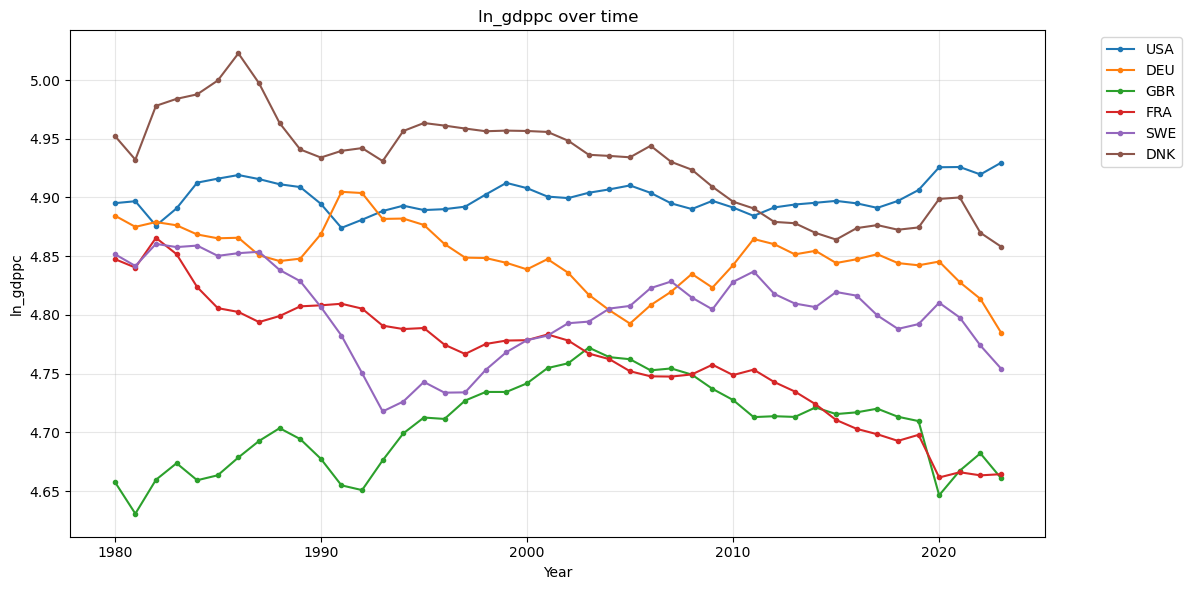

In [11]:
from clean import plot_time_series, plot_correlation_matrix
import matplotlib.pyplot as plt

# Plot GDP over time for selected countries
plot_time_series(
    master,
    'ln_gdppc',
    countries=['USA', 'DEU', 'GBR', 'FRA', 'SWE', 'DNK']
)

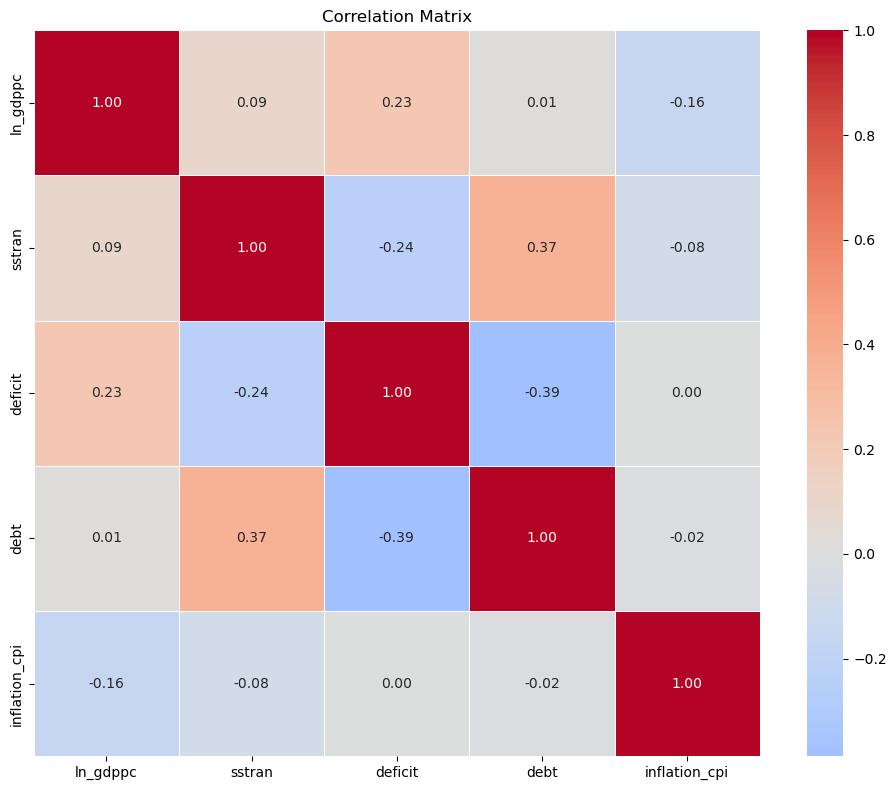

In [28]:
# Correlation heatmap
plot_correlation_matrix(
    master,
    variables=['ln_gdppc', 'sstran', 'deficit', 'debt', 'inflation_cpi']
)

### Average Social Security Transfers Across All Countries

In [ ]:
# Cross-country mean of social-security transfers over time.
# See src/analysis/trend_plots.py for the canonical implementation.
from analysis.trend_plots import plot_sstran_trend

png_path, _, agg = plot_sstran_trend(master_regimes, REPO_ROOT / "outputs" / "figures")
print(f"Saved figure to: {png_path}")
print(f"Period average: {agg['mean'].mean():.2f}% of GDP")

### Average KOF Globalization Indices Across All Countries

In [ ]:
# Cross-country mean of KOF globalization indices over time.
from analysis.trend_plots import plot_kof_trend

png_path, _, agg_kof = plot_kof_trend(master_regimes, REPO_ROOT / "outputs" / "figures")
print(f"Saved figure to: {png_path}")
print(f"KOFGI trend: {agg_kof['KOFGI'].iloc[0]:.1f} -> {agg_kof['KOFGI'].iloc[-1]:.1f}")

## Part 7: Filter by Country Groups

In [10]:
from clean import filter_by_region, list_regions

# See available regions
list_regions()

COUNTRY GROUPS

WESTERN EUROPE (17 countries):
  AUT, BEL, CHE, DEU, DNK, ESP, FIN, FRA, GBR, GRC, IRL, ITA, LUX, NLD, NOR, PRT, SWE

EASTERN EUROPE (9 countries):
  BGR, CZE, EST, HUN, LTU, LVA, POL, SVK, SVN

ANGLO (5 countries):
  AUS, CAN, GBR, NZL, USA

NORDIC (5 countries):
  DNK, FIN, ISL, NOR, SWE

EU FOUNDERS (6 countries):
  BEL, DEU, FRA, ITA, LUX, NLD

POST COMMUNIST (9 countries):
  BGR, CZE, EST, HUN, LTU, LVA, POL, SVK, SVN



## Part 7.5: Unbundling Globalization - Component Analysis

In this section, we decompose the aggregate Globalization indices into their specific sub-dimensions to identify the precise drivers of the welfare state relationship:
- **Economic**: Trade (`KOFTrGI`) vs. Financial (`KOFFiGI`)
- **Social**: Interpersonal (`KOFIpGI`), Informational (`KOFInGI`), and Cultural (`KOFCuGI`)

This "unbundling" helps distinguish between the **Race-to-the-Bottom** hypothesis (usually linked to trade and tax competition) and the **Compensation Hypothesis** (linked to economic insecurity from financial volatility).


In [ ]:
# KOF sub-component (trade/finance/interpersonal/information/cultural) regressions.
# See src/analysis/robustness.py::run_subcomponent_regressions for the canonical impl.
from analysis.robustness import export_subcomponent_regression_table

try:
    out_path = export_subcomponent_regression_table(master_regimes, config)
    print(f"Saved sub-component table to: {out_path}")
except ValueError as exc:
    print(f"Skipping sub-component table: {exc}")

## Part 8: Robustness Checks

### Robustness Checks: Testing the Stability of Our Results

A single regression result is never sufficient for credible empirical research. **Robustness checks** test whether our findings hold under alternative specifications and data treatments:

| Check | What it does | Why it matters |
|---|---|---|
| **Drop outliers** | Removes observations >3 standard deviations from the mean | Extreme values (e.g., hyperinflation) can drive results |
| **Winsorize** | Caps extreme values at the 1st/99th percentile instead of removing them | Less aggressive than dropping; preserves sample size |
| **Pre-2008** | Restricts sample to years before the Global Financial Crisis | Tests whether results are driven by the crisis period |
| **Post-2008** | Restricts sample to years after the crisis | Tests whether the relationship changed structurally |

If our core finding (the sign and significance of the globalisation coefficient) survives across all these specifications, we can be more confident that it reflects a genuine empirical relationship rather than an artefact of a particular sample or specification choice.

### Enhanced Robustness Analysis

We can now automatically generate high-resolution **Specification Curves** and a **Robustness Summary**.
The summary table shows the percentage of model specifications where each control variable remained statistically significant.

## Setup

In [12]:
from clean.robustness import run_robustness_checks, compare_robustness_results
from statsmodels.formula.api import ols

# Run model with automated robustness checks
robust_results = run_robustness_checks(
    master_with_lags,
    'sstran ~ ln_gdppc + deficit + ln_gdppc_lag1',
    ols,
    checks=['drop_outliers', 'winsorize', 'pre_2008', 'post_2008']
)

Running baseline model...
Running robustness check: drop_outliers
✅ drop_outliers: 1196 observations
Running robustness check: winsorize
✅ winsorize: 1408 observations
Running robustness check: pre_2008
✅ pre_2008: 896 observations
Running robustness check: post_2008
✅ post_2008: 512 observations


In [11]:
# Compare coefficients across specifications
comparison = compare_robustness_results(robust_results, variable='ln_gdppc')

NameError: name 'robust_results' is not defined

## Part 10: Generate Methods Section

In [12]:
from clean import generate_methods_section

# Auto-generate data section for paper
methods = generate_methods_section(
    master,
    output_path=REPO_ROOT / "paper" / "methods.md"
)

print("Methods section generated! Preview:")
print(methods[:500] + "...")

✅ Methods section saved to: C:\Users\Anton\economics-of-the-welfare-state\paper\methods.md
Methods section generated! Preview:
# Data and Methods

## Data Sources

This study utilizes panel data from multiple sources:


**CPDS:**
- *Social security transfers* (`sstran`)
- *Government deficit* (`deficit`)
- *Government debt* (`debt`)

**World Bank:**
- *Log population* (`ln_population`)
- *Inflation rate* (`inflation_cpi`)
- *Age dependency ratio* (`dependency_ratio`)

**World Bank / OECD:**
- *Log GDP per capita* (`ln_gdppc`)

## Sample

The analysis covers **32 countries** over the period **1980–2023**, yielding **1,40...


## Part 11: Export to R/Stata

### Exporting for Other Statistical Software

Academic research teams often use multiple software packages. To ensure our cleaned dataset is accessible to all collaborators, we export:

- **R script** (`analysis.R`): Auto-generated with `library()` calls, panel data setup (`pdata.frame`), and sample model specifications using `fixest` and `plm`.
- **Stata do-file** (`analysis.do`): Auto-generated with `xtset`, variable labels, and sample `xtreg` commands.

These scripts serve as starting points — researchers can modify the model specifications while using the same cleaned data, ensuring reproducibility across teams and software.

In [39]:
from clean.export import export_to_r, export_to_stata_script

# Generate R script with pre-configured models
export_to_r(
    master_with_lags,
    REPO_ROOT / 'analysis' / 'analysis.R',
    include_packages=['fixest', 'plm', 'did']
)

# Generate Stata script
export_to_stata_script(
    master_with_lags,
    REPO_ROOT / 'analysis' / 'analysis.do'
)

✅ R script saved to: C:\Users\Anton\economics-of-the-welfare-state\analysis\analysis.R
✅ Data saved to: C:\Users\Anton\economics-of-the-welfare-state\analysis\master.csv

To use:
  1. Open R or RStudio
  2. Run: source('analysis.R')
✅ Stata script saved to: C:\Users\Anton\economics-of-the-welfare-state\analysis\analysis.do
✅ Data saved to: C:\Users\Anton\economics-of-the-welfare-state\analysis\master.dta


### Table 8: Correlation Matrix

In [ ]:
# Lagged-variable correlation matrix with significance stars.
# See src/analysis/correlations.py for the canonical implementation.
from analysis.correlations import export_correlation_matrix

csv_path, tex_path = export_correlation_matrix(master_regimes, REPO_ROOT / "outputs" / "tables")
print(f"Saved correlation matrix to {csv_path} and {tex_path}")

# Part 7: Baseline model

### Baseline Regressions: The Average Effect of Globalisation

Before examining whether the impact of globalisation depends on the welfare regime, we first estimate the **baseline effect** across all countries in our sample. These models provide the "average" relationship between globalisation and social security transfers, controlling for economic and demographic factors but *without* interaction terms.

We estimate four baseline models, one for each dimension of the KOF Globalisation Index. This allows us to see if, on average, more globalised countries (or those becoming more globalised) tend to spend more or less on social transfers.

In [ ]:
# Baseline regressions (no interactions) per KOF index.
# See src/analysis/robustness.py::run_baseline_regressions for the canonical impl.
from analysis.robustness import export_baseline_regression_table

out_path = export_baseline_regression_table(master_regimes, config)
print(f"Saved baseline table to: {out_path}")

In [15]:
from analysis.regression_utils import run_hausman_test, prepare_regression_data
from clean import create_lags

# ── Ensure 'reg_data' for KOFGI is specifically prepared ────────────
idx_name = 'KOFGI'
current_ctrl_vars = [idx_name] + config.get('controls')
reg_data_hausman = create_lags(master_regimes, current_ctrl_vars, lags=[1])

g_var = f'{idx_name}_lag1'
lagged_ctrls_hausman = [f'{v}_lag1' for v in current_ctrl_vars if v != idx_name]

# Prepare data and run the test
ols_data, exog_vars = prepare_regression_data(reg_data_hausman, 'sstran', g_var, lagged_ctrls_hausman)
hausman_result = run_hausman_test(ols_data, dep_var='sstran', exog_vars=exog_vars)
display(hausman_result)

,Hausman Statistic,Degrees of Freedom,P-Value,Verdict (α=0.05)
0,-137.9846,7,1.0,Fail to reject H₀ → Random Effects consistent


# Part 8: Heterogeneity across Welfare Regimes
Analyzing how the impact of globalization on social security transfers varies by welfare regime.

### Panel Fixed Effects Regression with Welfare Regime Interactions

This is the core econometric model of our analysis. We estimate a **two-way fixed effects (TWFE)** model:

$$sstran_{it} = \alpha_i + \gamma_t + \beta_1 \cdot Glob_{i,t-1} + \beta_2 \cdot (Glob_{i,t-1} \times Conservative_i) + \ldots + \mathbf{X}_{i,t-1}'\delta + \varepsilon_{it}$$

**Model components explained:**
- **$\alpha_i$ (Entity fixed effects):** Absorb all *time-invariant* differences between countries (geography, legal tradition, culture). This means we're estimating *within-country* variation only.
- **$\gamma_t$ (Time fixed effects):** Absorb all *country-invariant* shocks that affect all countries in a given year (e.g., global recessions, oil price shocks).
- **$\beta_1$ (Base globalisation effect):** The marginal effect of globalisation for the **reference group** (Social Democrat regimes).
- **Interaction terms ($\beta_2, \ldots, \beta_5$):** How much the globalisation effect *differs* for each regime relative to Social Democrats. The total effect for, say, Liberal regimes is $\beta_1 + \beta_4$.
- **Controls ($\mathbf{X}_{i,t-1}$):** Lagged GDP per capita, inflation, fiscal deficit, debt, population, and dependency ratio — all measured at $t-1$ to avoid simultaneity.
- **Clustered standard errors:** We cluster at the country level to account for serial correlation within countries over time, producing robust inference.

> **Interpretation:** A positive interaction coefficient (e.g., $\beta_{conservative} > 0$) means that globalisation increases social spending *more* in Conservative regimes than in Social Democrat ones.

### Creating Lag Variables for Dynamic Models

In panel data econometrics, we often use **lagged** (past-period) values of independent variables rather than contemporaneous ones. This serves two purposes:

1. **Temporal ordering / causality:** If we want to argue that globalisation *causes* changes in welfare spending, we need globalisation measured *before* the spending — i.e., `KOFGIₜ₋₁ → sstranₜ`. Using contemporaneous values (`KOFGIₜ → sstranₜ`) makes it impossible to distinguish cause from effect.

2. **Reducing simultaneity bias:** When two variables are determined at the same time (e.g., government spending and GDP), OLS estimates are biased. Lagging the independent variable breaks this simultaneity.

The `create_lags()` function generates new columns (e.g., `ln_gdppc_lag1`) by shifting each variable one period backward *within each country*, ensuring we don't accidentally use Country A's past value for Country B.

We also check **panel balance** here — whether all countries have the same number of time periods. An unbalanced panel is common in practice and is handled correctly by the fixed-effects estimator.

In [125]:
from analysis.robustness import export_interaction_excl_postcommunist_table

path = export_interaction_excl_postcommunist_table(master_regimes, config)
print(f"Interaction (excl. post-communist) table saved to: {path}")


In [ ]:
# Regime-interaction regressions per KOF index (canonical spec).
# See src/analysis/robustness.py::run_interaction_regressions for the canonical impl.
from analysis.robustness import (
    export_interaction_regression_table,
    export_marginal_effects_tables,
)

out_path = export_interaction_regression_table(master_regimes, config)
print(f"Saved interaction table to: {out_path}")

# Per-index marginal effects by welfare regime.
me_paths = export_marginal_effects_tables(master_regimes, config)
for idx_name, p in me_paths.items():
    print(f"Saved marginal-effects table for {idx_name} to: {p}")

### Comparative Regression Table (All Globalisation Dimensions)

The KOF Globalisation Index is composed of multiple dimensions:
- **KOFGI** — Overall Globalisation Index (composite)
- **KOFEcGI** — Economic Globalisation (trade openness, FDI, financial flows)
- **KOFSoGI** — Social Globalisation (information flows, cultural proximity, personal contacts)
- **KOFPoGI** — Political Globalisation (international organisations, treaties, embassies)

By running the **same model specification** with each dimension separately, we can assess *which aspect* of globalisation drives the relationship with welfare spending. This is important because the theoretical mechanisms differ:
- **Economic** globalisation creates competitive tax pressure (race to the bottom) or compensation demands.
- **Social** globalisation may spread welfare norms across countries.
- **Political** globalisation may constrain or enable domestic policy through international agreements.

The `compare()` function displays all four models side-by-side with significance stars (*** p<0.01, ** p<0.05, * p<0.10), and the result is exported as a **LaTeX table** for the paper.

## Part 8: Feedback Regressions (Globalization as Dependent Variable)

In this section, we investigate the "feedback" effect: does the size of the welfare state (measured by social security transfers) influence the level of globalization? 

We estimate four models where the dependent variables are the Overall, Economic, Social, and Political globalization indices. The primary independent variable is the lagged level of social security transfers (`sstran_lag1`).

### Feedback Regressions: Does Welfare Spending Affect Globalisation?

A common criticism of globalisation-welfare research is the possibility of **reverse causality**: perhaps it's not globalisation that drives welfare spending, but welfare spending that influences a country's degree of globalisation.

For example:
- Countries with generous welfare states may be *more open* to trade because their citizens feel protected against economic shocks (the **compensation hypothesis**).
- Alternatively, high social spending may *reduce* economic competitiveness, leading to *less* economic openness.

To investigate this, we **reverse the model**: now the globalisation indices are the *dependent* variables, and `sstran_lag1` (lagged social spending) is the key independent variable.

$$Glob_{it} = \alpha_i + \gamma_t + \phi \cdot sstran_{i,t-1} + \mathbf{X}_{i,t-1}'\delta + \varepsilon_{it}$$

If $\phi$ is statistically significant, it suggests a feedback loop exists — meaning the relationship runs in *both* directions and a more sophisticated model (e.g., a system of simultaneous equations or GMM) may be warranted.

> **Note:** This test does not conclusively prove or disprove causality — it is a suggestive diagnostic. True causal identification would require instrumental variables or a natural experiment.

In [ ]:
# Feedback (reverse-causality) regressions: globalization_t = f(sstran_{t-1}, ...).
# See src/analysis/robustness.py::run_feedback_regressions for the canonical impl.
from analysis.robustness import export_feedback_regression_table

out_path = export_feedback_regression_table(master_regimes, config)
print(f"Saved feedback table to: {out_path}")

## Stepwise Robustness Checks
We systematically add macroeconomic control variables one by one to see how sensitive the baseline results are to different configurations.

In [24]:
from analysis.robustness import export_stepwise_robustness_tables
from clean.utils import load_config

config = load_config()
# Single function call to handle stepwise robustness loop and export tables
export_stepwise_robustness_tables(master_regimes, config)


✅ Created KOFGI_lag1
✅ Created KOFGI_lag1
✅ Created ln_gdppc_lag1
✅ Created KOFGI_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created KOFGI_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created deficit_lag1
✅ Created KOFGI_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created deficit_lag1
✅ Created debt_lag1
✅ Created KOFGI_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created deficit_lag1
✅ Created debt_lag1
✅ Created ln_population_lag1
✅ Created KOFGI_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created deficit_lag1
✅ Created debt_lag1
✅ Created ln_population_lag1
✅ Created dependency_ratio_lag1

==================== Stepwise Robustness: KOFGI ====================


,Baseline,+ ln_gdppc,+ inflation_cpi,+ deficit,+ debt,+ ln_population,+ dependency_ratio
Dep. Variable,sstran,sstran,sstran,sstran,sstran,sstran,sstran
Estimator,PanelOLS,PanelOLS,PanelOLS,PanelOLS,PanelOLS,PanelOLS,PanelOLS
No. Observations,1243,1239,1232,1209,1187,1187,996
Cov. Est.,Clustered,Clustered,Clustered,Clustered,Clustered,Clustered,Clustered
R-squared,0.0359,0.2320,0.2346,0.3150,0.3778,0.3842,0.3583
R-Squared (Within),-0.1042,-0.3372,-0.3081,0.0338,0.1992,0.3052,0.3220
R-Squared (Between),0.1885,-0.6377,-0.6866,-0.5572,-0.1508,-2.5429,-5.4414
R-Squared (Overall),0.1042,-0.3935,-0.4027,-0.2355,0.0024,-1.6437,-3.9675
F-statistic,43.489,175.63,118.02,130.02,134.58,115.09,73.776
P-value (F-stat),0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


✅ Saved table to: ../outputs/tables/stepwise_robustness_KOFGI.tex
✅ Created KOFEcGI_lag1
✅ Created KOFEcGI_lag1
✅ Created ln_gdppc_lag1
✅ Created KOFEcGI_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created KOFEcGI_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created deficit_lag1
✅ Created KOFEcGI_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created deficit_lag1
✅ Created debt_lag1
✅ Created KOFEcGI_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created deficit_lag1
✅ Created debt_lag1
✅ Created ln_population_lag1
✅ Created KOFEcGI_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created deficit_lag1
✅ Created debt_lag1
✅ Created ln_population_lag1
✅ Created dependency_ratio_lag1

==================== Stepwise Robustness: KOFEcGI ====================


,Baseline,+ ln_gdppc,+ inflation_cpi,+ deficit,+ debt,+ ln_population,+ dependency_ratio
Dep. Variable,sstran,sstran,sstran,sstran,sstran,sstran,sstran
Estimator,PanelOLS,PanelOLS,PanelOLS,PanelOLS,PanelOLS,PanelOLS,PanelOLS
No. Observations,1243,1239,1232,1209,1187,1187,996
Cov. Est.,Clustered,Clustered,Clustered,Clustered,Clustered,Clustered,Clustered
R-squared,0.0409,0.1820,0.1920,0.2711,0.3645,0.3738,0.3523
R-Squared (Within),-0.0968,-0.0742,-0.0661,0.1918,0.2929,0.3530,0.2747
R-Squared (Between),0.0713,-0.7490,-0.8114,-0.6434,-0.1545,-3.6970,-10.053
R-Squared (Overall),0.0392,-0.3821,-0.4017,-0.2598,-0.0010,-2.4599,-7.4364
F-statistic,49.772,129.39,91.511,105.18,127.09,110.12,71.867
P-value (F-stat),0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


✅ Saved table to: ../outputs/tables/stepwise_robustness_KOFEcGI.tex
✅ Created KOFSoGI_lag1
✅ Created KOFSoGI_lag1
✅ Created ln_gdppc_lag1
✅ Created KOFSoGI_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created KOFSoGI_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created deficit_lag1
✅ Created KOFSoGI_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created deficit_lag1
✅ Created debt_lag1
✅ Created KOFSoGI_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created deficit_lag1
✅ Created debt_lag1
✅ Created ln_population_lag1
✅ Created KOFSoGI_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created deficit_lag1
✅ Created debt_lag1
✅ Created ln_population_lag1
✅ Created dependency_ratio_lag1

==================== Stepwise Robustness: KOFSoGI ====================


,Baseline,+ ln_gdppc,+ inflation_cpi,+ deficit,+ debt,+ ln_population,+ dependency_ratio
Dep. Variable,sstran,sstran,sstran,sstran,sstran,sstran,sstran
Estimator,PanelOLS,PanelOLS,PanelOLS,PanelOLS,PanelOLS,PanelOLS,PanelOLS
No. Observations,1243,1239,1232,1209,1187,1187,996
Cov. Est.,Clustered,Clustered,Clustered,Clustered,Clustered,Clustered,Clustered
R-squared,0.0175,0.2064,0.2110,0.2892,0.3837,0.3892,0.3706
R-Squared (Within),-0.0448,-0.2354,-0.2092,0.1122,0.1745,0.2893,0.3174
R-Squared (Between),-0.0547,-1.0397,-1.0837,-0.8595,-0.2925,-2.6779,-4.4064
R-Squared (Overall),-0.0567,-0.6732,-0.6769,-0.4687,-0.1331,-1.7655,-3.2069
F-statistic,20.790,151.28,102.97,115.03,137.94,117.54,77.807
P-value (F-stat),0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


✅ Saved table to: ../outputs/tables/stepwise_robustness_KOFSoGI.tex
✅ Created KOFPoGI_lag1
✅ Created KOFPoGI_lag1
✅ Created ln_gdppc_lag1
✅ Created KOFPoGI_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created KOFPoGI_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created deficit_lag1
✅ Created KOFPoGI_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created deficit_lag1
✅ Created debt_lag1
✅ Created KOFPoGI_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created deficit_lag1
✅ Created debt_lag1
✅ Created ln_population_lag1
✅ Created KOFPoGI_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created deficit_lag1
✅ Created debt_lag1
✅ Created ln_population_lag1
✅ Created dependency_ratio_lag1

==================== Stepwise Robustness: KOFPoGI ====================


,Baseline,+ ln_gdppc,+ inflation_cpi,+ deficit,+ debt,+ ln_population,+ dependency_ratio
Dep. Variable,sstran,sstran,sstran,sstran,sstran,sstran,sstran
Estimator,PanelOLS,PanelOLS,PanelOLS,PanelOLS,PanelOLS,PanelOLS,PanelOLS
No. Observations,1243,1239,1232,1209,1187,1187,996
Cov. Est.,Clustered,Clustered,Clustered,Clustered,Clustered,Clustered,Clustered
R-squared,0.0102,0.1621,0.1698,0.2665,0.3654,0.3765,0.3579
R-Squared (Within),0.0057,0.0578,0.0657,0.2341,0.3170,0.3582,0.3120
R-Squared (Between),0.1595,-0.6287,-0.6717,-0.5676,-0.1669,-3.6536,-7.3221
R-Squared (Overall),0.1126,-0.3026,-0.3209,-0.2088,0.0077,-2.4364,-5.3812
F-statistic,12.071,112.49,78.760,102.72,127.62,111.40,73.664
P-value (F-stat),0.0005,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


✅ Saved table to: ../outputs/tables/stepwise_robustness_KOFPoGI.tex


### Subperiod Regressions: Testing for Structural Breaks

Here we evaluate the relationship over distinct historical eras like Pre/Post WTO (1995), the China Shock (2000), and the Global Financial Crisis (2008).

In [16]:
from analysis.robustness import export_subperiod_regressions
from analysis.robustness import export_event_study_plots

# Run and export subperiod regression tables
export_subperiod_regressions(master_regimes, config)
# Run and export event study plots around China Shock
export_event_study_plots(master_regimes, config)



🕰️ RUNNING SUBPERIOD REGRESSIONS (Pre vs Post China Shock)
  Generated table for pre_china_shock with 4 indices
  Generated table for post_china_shock with 4 indices



### Structural Break Tests: Validating the 2000 Split Point

The subperiod regressions above assume that 2000 (China\'s WTO accession) is the correct breakpoint. 
Here we *formally test* that assumption using two complementary econometric methods:

| Test | What it does |
|---|---|
| **Chow Test** | F-test of equal coefficients pre/post 2000 (known break) |
| **QLR / Sup-Wald** | Finds the *most likely* unknkown break date (Andrews 1993) |

Rolling OLS coefficient plots are also exported to `outputs/figures/` to visually inspect how the globalization effect drifts over time.

In [17]:
from clean.structural_breaks import export_structural_breaks_latex

# ── Structural Break Tests ─────────────────────────────────────────────────
# Tests the stability of the globalization → welfare spending relationship.
# Exports:
#   outputs/tables/chow_test_table.tex  — Chow F-test at year 2000
#   outputs/tables/qlr_test_table.tex   — Sup-Wald test (unknown break date)
#   outputs/figures/rolling_ols_*.png   — 10-year rolling OLS coefficient plots
#   outputs/figures/qlr_path_*.png      — QLR F-statistic path plots
export_structural_breaks_latex(
    master_regimes,
    config=config,
)


🔍 STRUCTURAL BREAK TESTS
   Break year (Chow): 2000  |  Panel: 1980–2023
   Indices: KOFGI, KOFEcGI, KOFSoGI, KOFPoGI

  ── Globalization (Overall) (KOFGI) ──
     Chow test (break=2000)... F=4.484, p=0.000 → ✓ Break detected ✓
     QLR test (unknown break)... 

C:\Users\Anton\economics-of-the-welfare-state\src\clean\structural_breaks.py:152: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pre = data[df[time_var] < break_year].copy()
C:\Users\Anton\economics-of-the-welfare-state\src\clean\structural_breaks.py:153: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  post = data[df[time_var] >= break_year].copy()


Sup-F=12.895, est. break=1995 → Break detected ✓ (p<0.01)
     Rolling OLS (10-year window)... computed 33 windows

  ── Globalization (Economic) (KOFEcGI) ──
     Chow test (break=2000)... F=3.556, p=0.001 → ✓ Break detected ✓
     QLR test (unknown break)... Sup-F=16.080, est. break=1995 → Break detected ✓ (p<0.01)


C:\Users\Anton\economics-of-the-welfare-state\src\clean\structural_breaks.py:152: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pre = data[df[time_var] < break_year].copy()
C:\Users\Anton\economics-of-the-welfare-state\src\clean\structural_breaks.py:153: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  post = data[df[time_var] >= break_year].copy()


     Rolling OLS (10-year window)... computed 33 windows

  ── Globalization (Social) (KOFSoGI) ──
     Chow test (break=2000)... F=2.912, p=0.005 → ✓ Break detected ✓
     QLR test (unknown break)... Sup-F=10.855, est. break=1995 → Break detected ✓ (p<0.05)


C:\Users\Anton\economics-of-the-welfare-state\src\clean\structural_breaks.py:152: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pre = data[df[time_var] < break_year].copy()
C:\Users\Anton\economics-of-the-welfare-state\src\clean\structural_breaks.py:153: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  post = data[df[time_var] >= break_year].copy()


     Rolling OLS (10-year window)... computed 33 windows

  ── Globalization (Political) (KOFPoGI) ──
     Chow test (break=2000)... F=4.279, p=0.000 → ✓ Break detected ✓
     QLR test (unknown break)... Sup-F=11.552, est. break=1995 → Break detected ✓ (p<0.05)


C:\Users\Anton\economics-of-the-welfare-state\src\clean\structural_breaks.py:152: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pre = data[df[time_var] < break_year].copy()
C:\Users\Anton\economics-of-the-welfare-state\src\clean\structural_breaks.py:153: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  post = data[df[time_var] >= break_year].copy()


     Rolling OLS (10-year window)... computed 33 windows

  Exporting LaTeX tables...
  ✅ Saved: chow_test_table.tex
  ✅ Saved: qlr_test_table.tex

